In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression


In [107]:
df = pd.read_csv('/run/media/awongo-fahadi-rashid/AFRAH/Projects/Recess Term/Lectures/Datasets/Customer-Churn.csv')

In [108]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [109]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [110]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Text(119.58333333333333, 0.5, 'Count')

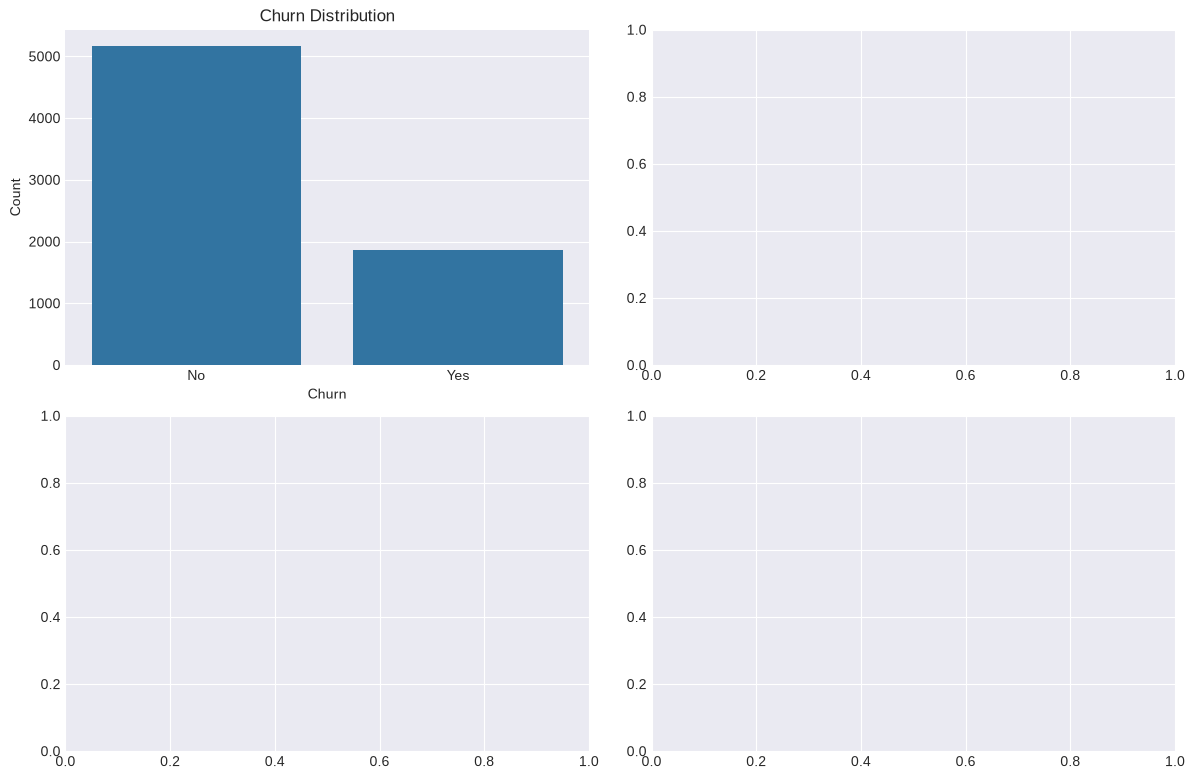

In [111]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2,2, figsize=(12, 8))
plt.tight_layout(pad=2.0)
sns.barplot(x=df['Churn'].value_counts().index, y=df['Churn'].value_counts().values, ax=axes[0,0])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xlabel('Churn')
axes[0,0].set_ylabel('Count')

In [112]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [113]:
# Check for data types of each column
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [114]:
# check and clean for missing values in the dataset
cleaned = df.replace(' ', np.nan, regex=True)
cleaned.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines        682
InternetService     3096
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
Contract            3168
PaperlessBilling       0
PaymentMethod       7043
MonthlyCharges         0
TotalCharges          11
Churn                  0
dtype: int64

In [115]:
import pandas as pd
import warnings
# warnings.filterwarnings('ignore')

# 1. Convert 'TotalCharges' column to numeric type
columns_to_convert = ['TotalCharges', 'MonthlyCharges']
for col in columns_to_convert:
    cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')

# 2. FIX: Explicitly reassign the column instead of using inplace=True
for col in columns_to_convert:
    cleaned[col] = cleaned[col].fillna(cleaned[col].median())

In [116]:
cleaned.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines        682
InternetService     3096
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
Contract            3168
PaperlessBilling       0
PaymentMethod       7043
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

In [117]:
cleaned.head(100)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,NaN,DSL,No,...,No,No,No,No,Month-to-month,Yes,NaN,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,NaN,No,NaN,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,NaN,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,NaN,DSL,Yes,...,Yes,Yes,No,No,NaN,No,NaN,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,NaN,No,...,No,No,No,No,Month-to-month,Yes,NaN,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,8637-XJIVR,Female,0,No,No,12,Yes,Yes,NaN,Yes,...,No,No,No,No,Month-to-month,Yes,NaN,78.95,927.35,Yes
96,9803-FTJCG,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,NaN,Yes,NaN,66.85,4748.70,No
97,0278-YXOOG,Male,0,No,No,5,Yes,No,No,NaN,...,NaN,NaN,NaN,NaN,Month-to-month,No,NaN,21.05,113.85,Yes
98,3212-KXOCR,Male,0,No,No,52,Yes,No,No,NaN,...,NaN,NaN,NaN,NaN,NaN,No,NaN,21.00,1107.20,No
